# Classifying Documents

Project of [Gen AI Foundational Models for NLP & Language Understanding](https://www.coursera.org/learn/gen-ai-foundational-models-for-nlp-and-language-understanding/home/welcome), Module 1.

In this project, I build a NN model using PyTorch and torchtext to categorize news articles into one of the four categories: World, Sports, Business, and Sci/Tech.

## Setup


### Install required libraries


In [ ]:
%%capture

!pip install -q numpy pandas matplotlib seaborn scikit-learn
# - Update a specific package
!pip install pmdarima -U
# - Update a package to specific version
!pip install --upgrade pmdarima==2.0.2

!pip install -Uqq portalocker>=2.0.0
!pip install -qq torchtext
!pip install -qq torchdata
!pip install -Uqq plotly
!pip install -qq dash
!pip install -qq nbformat


### Import required libraries


In [1]:
import torchtext; torchtext.disable_torchtext_deprecation_warning()

from tqdm import tqdm
import matplotlib.pyplot as plt
from torchtext.data.utils import get_tokenizer

import torch
from torch import nn

from torch.utils.data import DataLoader
from torchtext.datasets import AG_NEWS
from IPython.display import Markdown as md

from torchtext.vocab import build_vocab_from_iterator
from torchtext.datasets import AG_NEWS
from torch.utils.data.dataset import random_split
from torchtext.data.functional import to_map_style_dataset
from sklearn.manifold import TSNE
import plotly.graph_objs as go

from torchtext.data.utils import get_tokenizer

# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

### Define helper function


In [ ]:
def plot(COST,ACC):
    fig, ax1 = plt.subplots()
    color = 'tab:red'
    ax1.plot(COST, color=color)
    ax1.set_xlabel('epoch', color=color)
    ax1.set_ylabel('total loss', color=color)
    ax1.tick_params(axis='y', color=color)
    
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('accuracy', color=color)  # x-label is already handled with ax1
    ax2.plot(ACC, color=color)
    ax2.tick_params(axis='y', color=color)
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    
    plt.show()

## Model initialisation


### Import bank dataset

Load the AG_NEWS dataset.


In [ ]:
train_iter = iter(AG_NEWS(split="train"))
ag_news_label = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tec"}

Get example entry.

In [ ]:
y, text = next(train_iter)
print("Category:", y, "(" + ag_news_label[y] + ")")
print(text)

Category: 3 (Business)
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


Count number of classes.

In [536]:
num_class = len(set([label for (label, _) in train_iter]))
print("Number of classes:", num_class)

Number of classes: 4


Build vocabulary.

In [537]:
# Reinitialize train_iter
train_iter = AG_NEWS(split="train")

# Define tokenizer and yield_tokens
tokenizer = get_tokenizer("basic_english")

def yield_tokens(data_iter):
    for _, text in data_iter:
        yield tokenizer(text.lower())  # Lowercase conversion for consistency

# Build vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_iter), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

# Print the vocabulary size and sample tokens
print(f"Vocabulary size: {len(vocab)}")
print(f"Sample tokens: {list(vocab.get_stoi().keys())[:10]}")


Vocabulary size: 95811
Sample tokens: ['television', 'misnomer', 'television-watching', 'new', 'costs', '7-week', 'dutch', '35-10', 'tarceva', 'confidence']


Get example token indices.

In [ ]:
print("Indices:", vocab(["age", "hello"]))

Indices: [2120, 12544]


### Dataset 


Split data into train, validation and test.

In [ ]:
# Split the dataset into training and testing iterators
train_iter, test_iter = AG_NEWS()

# Convert the training and testing iterators to map-style datasets
train_dataset = to_map_style_dataset(train_iter)
test_dataset = to_map_style_dataset(test_iter)

# Randomly split the training dataset into training and validation datasets (with a 95:5 split)
num_train = int(len(train_dataset) * 0.95)
split_train, split_valid = random_split(train_dataset, [num_train, len(train_dataset) - num_train])

Checks if CUDA-compatible GPU is available in the system. If so, run code on GPU. Otherwise, run code on CPU.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Data loader


Prepare the text and label pipeline.

In [ ]:
def text_pipeline(x):
  return vocab(tokenizer(x))

def label_pipeline(x):
   return int(x) - 1  # Start at 0 instead of 1

Define batch processing function.

In [ ]:
def collate_batch(batch):
    label_list, text_list = [], []
    # Starting positions of each text sequence in the combined tensor
    offsets = [0]
    for label, text in batch:
        label_list.append(label_pipeline(label))
        processed_text = torch.tensor(text_pipeline(text), dtype=torch.int64)
        text_list.append(processed_text)
        offsets.append(processed_text.size(0))
    label_list = torch.tensor(label_list, dtype=torch.int64)
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
    text_list = torch.cat(text_list)
    return label_list.to(device), text_list.to(device), offsets.to(device)

Convert the dataset objects to a data loader by applying the collate function.


In [ ]:
BATCH_SIZE = 64

train_dataloader = DataLoader(
    split_train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
valid_dataloader = DataLoader(
    split_valid, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)

Observe the output sequence.


In [ ]:
label, text, offsets = next(iter(valid_dataloader))
label, text, offsets

(tensor([2, 1, 3, 1, 0, 1, 1, 3, 3, 2, 2, 2, 2, 2, 2, 3, 2, 2, 3, 3, 2, 0, 2, 3,
         3, 2, 3, 0, 3, 1, 1, 3, 1, 2, 3, 2, 2, 2, 3, 2, 1, 2, 1, 2, 2, 0, 3, 3,
         1, 2, 0, 0, 1, 1, 3, 2, 3, 1, 3, 1, 2, 1, 0, 2]),
 tensor([ 117, 1335,   46,  ...,  956,  530,    1]),
 tensor([   0,   40,   83,  122,  181,  221,  260,  303,  329,  365,  412,  446,
          490,  532,  562,  591,  617,  665,  696,  760,  794,  843,  889,  925,
          977, 1028, 1073, 1103, 1137, 1174, 1214, 1253, 1289, 1330, 1384, 1416,
         1436, 1484, 1521, 1568, 1616, 1665, 1702, 1734, 1780, 1814, 1856, 1928,
         1964, 2003, 2079, 2127, 2174, 2202, 2240, 2275, 2333, 2373, 2405, 2458,
         2501, 2538, 2578, 2630]))

### Create model


In [15]:
class TextClassificationModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_class):
        super(TextClassificationModel, self).__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=False)
        self.fc = nn.Linear(embed_dim, num_class)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, text, offsets):
        embedded = self.embedding(text, offsets)
        return self.fc(embedded)

In [ ]:
embedding_dimension_size=64
vocab_size=len(vocab)
model = TextClassificationModel(len(vocab), embedding_dimension_size, num_class).to(device)
model

TextClassificationModel(
  (embedding): EmbeddingBag(95811, 64, mode='mean')
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

Get predicted labels.


In [ ]:
predicted_label = model(text, offsets)

Verify output shape of model. The model is trained with a mini-batch size of 64 samples. The output layer produces four logits for each neuron, corresponding to the four classes in the classification task.


In [21]:
predicted_label.shape

torch.Size([64, 4])

Define function to predict label.

In [22]:
def predict(text, text_pipeline):
    with torch.no_grad():
        text = torch.tensor(text_pipeline(text))
        output = model(text, torch.tensor([0]))
        return ag_news_label[output.argmax(1).item() + 1]

Example prediction

In [ ]:
predict("I like sports", text_pipeline)

'Sci/Tec'

Create a function to evaluate the model's accuracy on a dataset.


In [ ]:
def evaluate(dataloader):
    model.eval()
    total_acc, total_count = 0, 0

    with torch.no_grad():
        for idx, (label, text, offsets) in enumerate(dataloader):
            predicted_label = model(text, offsets)

            total_acc += (predicted_label.argmax(1) == label).sum().item()
            total_count += label.size(0)
    return total_acc / total_count

Evaluate the model. It performs poorly, which is expected, given that the model hasn't been trained yet.


In [25]:
evaluate(test_dataloader)

0.2657894736842105

## Model training

- Set the learning rate (LR) to 0.1, which determines the step size for updating the model's parameters during training.

- CrossEntropyLoss is used to calculate the loss between the model's predicted outputs and the ground truth labels. This loss function is commonly employed for multi-class classification tasks.

- The chosen optimizer is Stochastic Gradient Descent (SGD), which optimizes the model's parameters based on the computed gradients with respect to the loss function. The SGD optimizer uses the specified learning rate to control the size of the weight updates.


In [ ]:
LR = 0.1

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

Train the model.


In [ ]:
EPOCHS = 10
cum_loss_list = []
acc_epoch = []
acc_old = 0

for epoch in tqdm(range(1, EPOCHS + 1)):
    model.train()
    cum_loss = 0
    for idx, (label, text, offsets) in enumerate(train_dataloader):
        optimizer.zero_grad()
        predicted_label = model(text, offsets)
        loss = criterion(predicted_label, label)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        optimizer.step()
        cum_loss += loss.item()

    cum_loss_list.append(cum_loss)
    accu_val = evaluate(valid_dataloader)
    acc_epoch.append(accu_val)

    if accu_val > acc_old:
        acc_old = accu_val
        torch.save(model.state_dict(), 'my_model.pth')

# To load model:
# model.load_state_dict(torch.load('my_model.pth'))

100%|██████████| 10/10 [04:31<00:00, 27.15s/it]


## Model evaluation

Plot the cost and accuracy for each epoch. With just ten epochs, the accuracy is over 80% on the validation data.


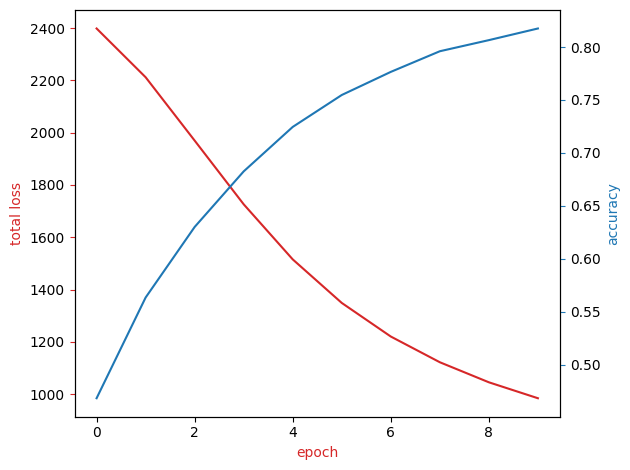

In [28]:
plot(cum_loss_list,acc_epoch)

Get accuracy of final epoch.


In [29]:
evaluate(test_dataloader)

0.8205263157894737

Generate a 3D t-SNE visualization of embeddings using Plotly. This demonstrates how words that are similar to each other are positioned closer together.


In [ ]:
# Get the first batch from the validation data
batch = next(iter(valid_dataloader))

# Extract the text and offsets from the batch
label, text, offsets = batch

# Send the data to the device (GPU if available)
text = text.to(device)
offsets = offsets.to(device)

# Get the embeddings bag output for the batch
embedded = model.embedding(text, offsets)

# Convert the embeddings tensor to a numpy array
embeddings_numpy = embedded.detach().cpu().numpy()

# Perform t-SNE on the embeddings to reduce their dimensionality to 3D.
X_embedded_3d = TSNE(n_components=3).fit_transform(embeddings_numpy)

# Create a 3D scatter plot using Plotly
trace = go.Scatter3d(
    x=X_embedded_3d[:, 0],
    y=X_embedded_3d[:, 1],
    z=X_embedded_3d[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=label.numpy(),  # Use label information for color
        colorscale='Viridis',  # Choose a colorscale
        opacity=0.8
    )
)

layout = go.Layout(title="3D t-SNE Visualization of Embeddings",
                   scene=dict(xaxis_title='Dimension 1',
                              yaxis_title='Dimension 2',
                              zaxis_title='Dimension 3'))

fig = go.Figure(data=[trace], layout=layout)
fig.show()

### Make predictions


In [44]:
new_articles = [
    "International talks have made significant headway with the signing of a climate accord that commits countries to reduce emissions by 40% over the next two decades. World leaders expressed optimism at the conclusion of the summit.",
    "In a stunning upset, the underdog team won the national title, beating the favorites in a match that featured an incredible comeback and a last-minute goal that sealed their victory in front of a record crowd.",
    "Market analysts are optimistic as the tech startup's stock prices soared after the announcement of their latest product, which promises to revolutionize how we interact with smart devices.",
    "A recent study published in a leading scientific journal suggests that a new drug has shown promise in the treatment of Alzheimer's disease, outperforming current leading medications in early clinical trials.",
    "Diplomatic relations have taken a positive turn with the recent peace talks that aim to end decades of conflict. The ceasefire agreement has been welcomed by the international community.",
    "Economic indicators show a sharp rebound in manufacturing, with the automobile industry leading the charge. Analysts predict this surge will result in significant job creation over the next year.",
    "Researchers at the university's astrophysics department have discovered a potentially habitable exoplanet. The planet, which lies in a nearby star system, has conditions that could support liquid water and, possibly, life.",
    "The sports world is in shock as a legendary player announces their retirement. Over an illustrious 20-year career, the athlete has amassed numerous records and is regarded as one of the greatest to ever play the game.",
    "A multinational corporation has announced a major investment in renewable energy. The initiative includes the construction of new wind farms and solar panels that will power hundreds of thousands of homes.",
]

Classify each article and display the results.


In [45]:
for i, article in enumerate(new_articles, start=1):
    prediction = predict(article, text_pipeline)
    print(f"Article {i}: {article}\nClassified as: {prediction}\n")

Article 1: International talks have made significant headway with the signing of a climate accord that commits countries to reduce emissions by 40% over the next two decades. World leaders expressed optimism at the conclusion of the summit.
Classified as: World

Article 2: In a stunning upset, the underdog team won the national title, beating the favorites in a match that featured an incredible comeback and a last-minute goal that sealed their victory in front of a record crowd.
Classified as: Sports

Article 3: Market analysts are optimistic as the tech startup's stock prices soared after the announcement of their latest product, which promises to revolutionize how we interact with smart devices.
Classified as: Business

Article 4: A recent study published in a leading scientific journal suggests that a new drug has shown promise in the treatment of Alzheimer's disease, outperforming current leading medications in early clinical trials.
Classified as: Sci/Tec

Article 5: Diplomatic re